# PCA50 summary (nested 5x3)

Consolidacion reproducible PCA50 usando solo `outputs_nested5x3`, con orden estable por bloques de modelos y heatmap agrupado por tipo de trait.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Global font scaling (+2) for publication readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 14,
})


In [2]:
root = Path.cwd().resolve()
if not (root / 'outputs_nested5x3').exists():
    candidates = [
        root / 'repo',
        root / 'nested5x3_unificados',
        root.parent,
        root.parent / 'repo',
        root.parent / 'nested5x3_unificados',
    ]
    for cand in candidates:
        if (cand / 'outputs_nested5x3').exists():
            root = cand
            break

source_base = root / 'outputs_nested5x3'
out_dir = root / 'results' / 'pca50_summary_nested5x3'
out_dir.mkdir(parents=True, exist_ok=True)

sources = {
    '11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3/summary_nested5x3.csv': '11_pca50_svr_unificado_nested5x3.ipynb',
    '21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3/summary_nested5x3.csv': '21_pca50_tree_unificado_nested5x3.ipynb',
    '40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3/summary_nested5x3.csv': '40_pca50_ensemble_unificado_nested5x3.ipynb',
    '45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3/summary_nested5x3.csv': '45_pca50_blocks_unificado_nested5x3.ipynb',
}

model_map = {
    'ridge': 'ridge',
    'elasticnet': 'elastic_net',
    'svr_linear': 'svr_linear',
    'svr_rbf': 'svr_rbf',
    'decision_tree': 'decision_tree',
    'random_forest': 'random_forest',
    'gradient_boosting': 'gradient_boosting',
    'adaboost': 'adaboost',
    'xgboost': 'xgboost',
}

# Orden estable por bloques de modelos
model_order = [
    'ridge', 'elastic_net',
    'svr_linear', 'svr_rbf',
    'decision_tree', 'random_forest', 'gradient_boosting', 'adaboost', 'xgboost'
]

# Agrupacion de traits en la misma grafica: enfermedades + agronomicos
trait_disease = ['blumeria_graminis', 'puccinia_hordei', 'ramularia_collo_cygni', 'rhynchosporium']
trait_agronomic = ['heading_date', 'lodging', 'plant_height']


In [3]:
frames = []
for rel_path, notebook_name in sources.items():
    file_path = source_base / rel_path
    df = pd.read_csv(file_path)
    keep = df[['representation', 'model', 'trait', 'pearson_r', 'r2', 'rmse', 'mae']].copy()
    keep['representation'] = 'PCA50'
    keep['model'] = keep['model'].str.strip().str.lower().map(model_map).fillna(keep['model'].str.strip().str.lower())
    keep['trait'] = keep['trait'].str.strip().str.lower()
    keep['source_file'] = file_path.as_posix()
    keep['source_notebook'] = f'nested5x3_unificados/{notebook_name}'
    keep['notes'] = ''
    frames.append(keep)

master = pd.concat(frames, ignore_index=True)
master = master.drop_duplicates(['representation', 'model', 'trait'])

# Completa orden de traits por grupos y aÃ±ade extras al final si aparecen
extra_traits = [t for t in sorted(master['trait'].unique()) if t not in set(trait_disease + trait_agronomic)]
trait_order = trait_disease + trait_agronomic + extra_traits

master['model'] = pd.Categorical(master['model'], categories=model_order, ordered=True)
master['trait'] = pd.Categorical(master['trait'], categories=trait_order, ordered=True)
master = master.sort_values(['model', 'trait']).reset_index(drop=True)

master.head()

,representation,model,trait,pearson_r,r2,rmse,mae,source_file,source_notebook,notes
0,PCA50,ridge,blumeria_graminis,0.722202,0.520465,0.806014,0.634289,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,nested5x3_unificados/45_pca50_blocks_unificado...,
1,PCA50,ridge,puccinia_hordei,0.657093,0.431631,0.896119,0.682086,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,nested5x3_unificados/45_pca50_blocks_unificado...,
2,PCA50,ridge,ramularia_collo_cygni,0.332085,0.109832,1.057651,0.821321,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,nested5x3_unificados/45_pca50_blocks_unificado...,
3,PCA50,ridge,rhynchosporium,0.209756,0.043749,0.895028,0.561704,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,nested5x3_unificados/45_pca50_blocks_unificado...,
4,PCA50,ridge,heading_date,0.772326,0.593968,20.248294,14.364245,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,nested5x3_unificados/45_pca50_blocks_unificado...,


In [4]:
# Metricas de resumen por modelo
rank_df = master.copy()
rank_df['rank_pearson'] = rank_df.groupby('trait', observed=True)['pearson_r'].rank(ascending=False, method='average')

best_by_trait = master.loc[master.groupby('trait', observed=True)['pearson_r'].idxmax(), ['trait', 'model']]
best_count = best_by_trait['model'].value_counts().rename('best_pearson_trait_count')

model_summary = (
    master.groupby('model', as_index=False, observed=True)
    .agg(
        mean_r=('pearson_r', 'mean'),
        median_pearson_r=('pearson_r', 'median'),
        std_pearson_r=('pearson_r', 'std'),
        mean_rank_pearson=('pearson_r', lambda s: rank_df.loc[s.index, 'rank_pearson'].mean()),
        mean_r2=('r2', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_mae=('mae', 'mean'),
        n_traits=('trait', 'nunique')
    )
)
model_summary['best_pearson_trait_count'] = model_summary['model'].map(best_count).fillna(0).astype(int)
model_summary = model_summary.sort_values('mean_r', ascending=False).reset_index(drop=True)
model_summary

,model,mean_r,median_pearson_r,std_pearson_r,mean_rank_pearson,mean_r2,mean_rmse,mean_mae,n_traits,best_pearson_trait_count
0,random_forest,0.635622,0.731778,0.254325,1.571429,0.454396,4.687699,3.301870,7,4
1,gradient_boosting,0.626905,0.722518,0.266818,2.857143,0.452803,4.682765,3.208709,7,2
2,xgboost,0.621908,0.712691,0.261347,4.428571,0.433475,4.743452,3.260439,7,0
3,elastic_net,0.621735,0.727560,0.253043,4.285714,0.439898,4.806273,3.440654,7,1
4,svr_rbf,0.621326,0.729331,0.269551,3.857143,0.443268,4.754251,3.050300,7,0
5,ridge,0.617000,0.722202,0.246020,4.857143,0.431411,4.829497,3.494500,7,0
6,adaboost,0.592995,0.716103,0.273060,7.142857,0.404488,5.066308,3.878100,7,0
7,svr_linear,0.585636,0.660439,0.251174,7.285714,0.361079,4.927162,3.286363,7,0
8,decision_tree,0.535133,0.677980,0.277845,8.714286,0.338241,5.551045,3.767611,7,0


In [5]:
master.to_csv(out_dir / 'pca50_nested5x3_master_results.csv', index=False)
model_summary.to_csv(out_dir / 'pca50_nested5x3_model_summary.csv', index=False)
print('saved tables in', out_dir)

saved tables in C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\pca50_summary_nested5x3


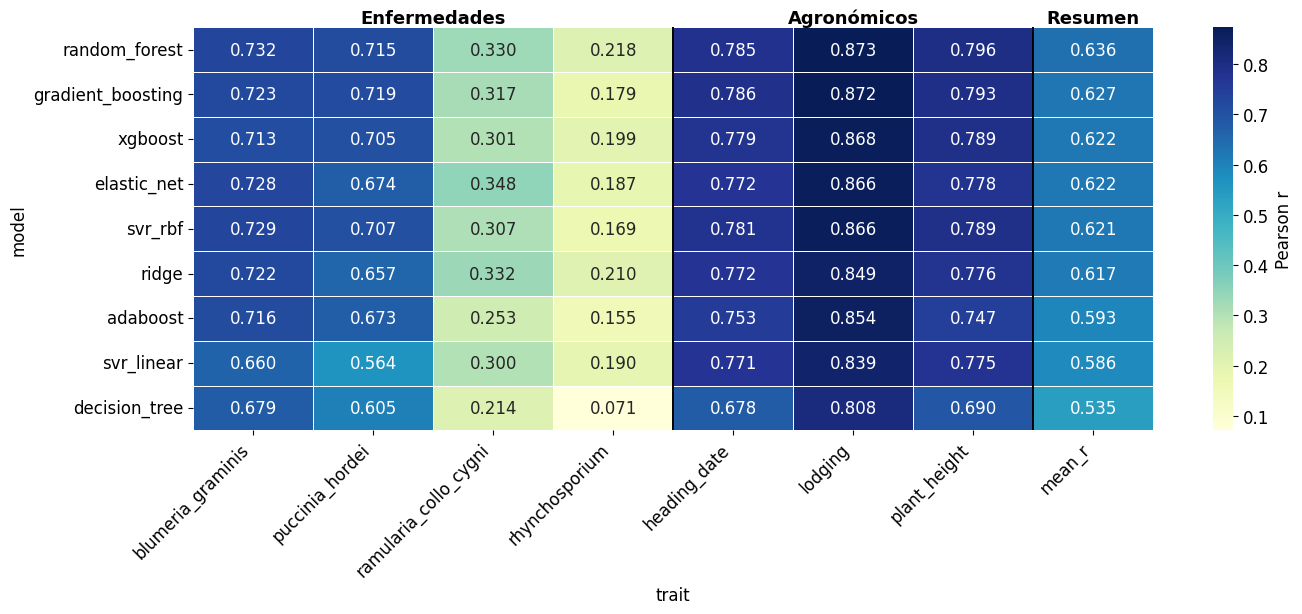

In [11]:
# Heatmap con orden de modelos por mean_r y columna final mean_r
pivot = master.pivot(index='model', columns='trait', values='pearson_r').reindex(columns=trait_order)
pivot['mean_r'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean_r', ascending=False)

heat_cols = trait_order + ['mean_r']

plt.figure(figsize=(15, 7.2))
ax = sns.heatmap(
    pivot[heat_cols],
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)

# Separación visual: enfermedades | agronómicos | resumen
ax.vlines([len(trait_disease), len(trait_order)], *ax.get_ylim(), colors='black', linewidth=1.4)

# Etiquetas de grupo arriba
y_top = -0.20
ax.text(len(trait_disease) / 2, y_top, 'Enfermedades',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(trait_disease) + len(trait_agronomic) / 2, y_top, 'Agronómicos',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(trait_order) + 0.5, y_top, 'Resumen',
        ha='center', va='center', fontsize=13, fontweight='bold')

# # Título y ejes
# ax.set_title('Rendimiento predictivo (Pearson r) por modelo y rasgo bajo representación PCA50',
#              pad=36, y=1.08)
# ax.set_xlabel('Trait')
# ax.set_ylabel('Model')

# Rotación de etiquetas del eje X
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajuste de márgenes
plt.subplots_adjust(top=0.82, bottom=0.26, left=0.16, right=0.96)

plt.savefig(out_dir / 'pca50_nested5x3_heatmap_pearson.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Reyes\AppData\Local\Temp\ipykernel_19264\1955327787.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["model"], rotation=35, ha="right")


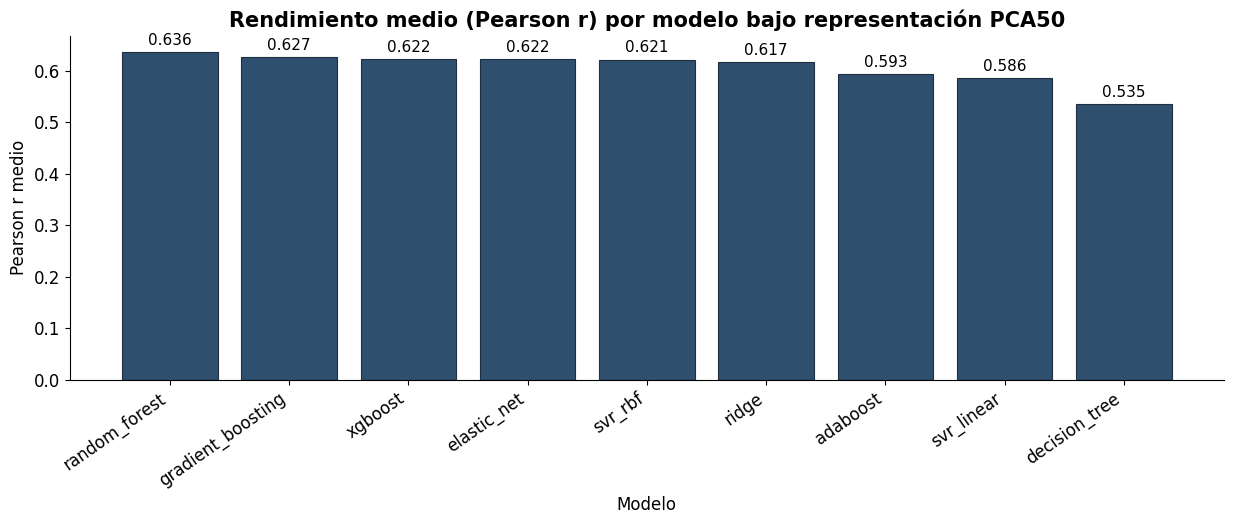

In [7]:
# Barplot PCA50: estilo académico + etiquetas (3 decimales)
plot_df = model_summary.sort_values("mean_r", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12.5, 5.4))
bars = ax.bar(
    plot_df["model"],
    plot_df["mean_r"],
    color="#2F4F6F",      # azul grisáceo serio
    edgecolor="#1F2F3F",
    linewidth=0.8
)

# Etiquetas en barras
for bar, v in zip(bars, plot_df["mean_r"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "Rendimiento medio (Pearson r) por modelo bajo representación PCA50",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Modelo")
ax.set_ylabel("Pearson r medio")
ax.set_xticklabels(plot_df["model"], rotation=35, ha="right")

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(out_dir / "pca50_nested5x3_barplot_mean_pearson.png", dpi=300, bbox_inches="tight")
plt.show()


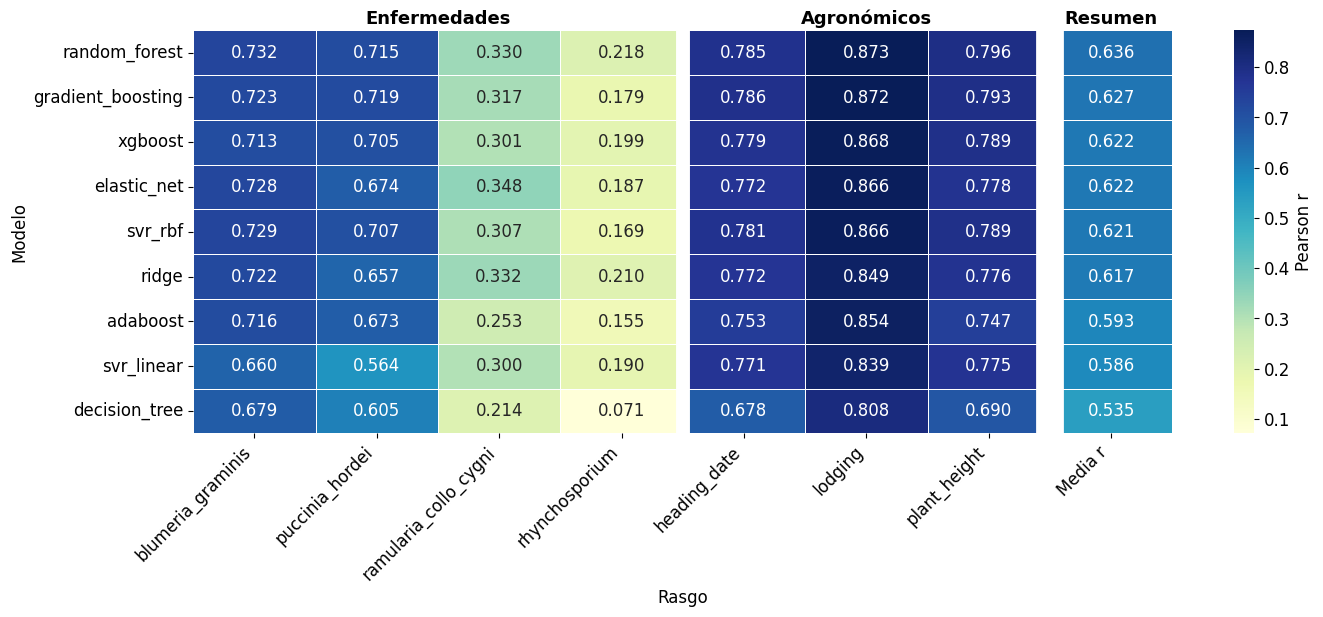

In [13]:
# =========================================================
# Heatmap PCA50 con separación visual limpia por líneas
# =========================================================

pivot = master.pivot(index='model', columns='trait', values='pearson_r').reindex(columns=trait_order)
pivot['mean_r'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean_r', ascending=False)

# Orden final SIN columnas extra
heat_cols = trait_disease + trait_agronomic + ['mean_r']
plot_data = pivot[heat_cols]

plt.figure(figsize=(15.3, 7.2))
ax = sns.heatmap(
    plot_data,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)

# Límites eje Y
ymin, ymax = ax.get_ylim()

# Separación enfermedades | agronómicos (suave)
ax.vlines(len(trait_disease), ymin, ymax, colors="#FFFFFF", linewidth=10)

# Separación antes de la media (más marcada)
ax.vlines(len(trait_disease) + len(trait_agronomic), ymin, ymax, colors="#FFFFFF", linewidth=20)

# Etiquetas superiores
y_top = -0.25
ax.text(len(trait_disease) / 2, y_top, 'Enfermedades',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(trait_disease) + len(trait_agronomic) / 2, y_top, 'Agronómicos',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(heat_cols) - 0.5, y_top, 'Resumen',
        ha='center', va='center', fontsize=13, fontweight='bold')

# # Título y ejes
# ax.set_title(
#     'Rendimiento predictivo (Pearson r) por modelo y rasgo bajo representación PCA50',
#     pad=36,
#     y=1.08
# )
ax.set_xlabel('Rasgo')
ax.set_ylabel('Modelo')

# Etiquetas eje X
xticklabels = trait_disease + trait_agronomic + ['Media r']
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Ajuste de márgenes
plt.subplots_adjust(top=0.82, bottom=0.26, left=0.16, right=0.96)

plt.savefig(
    out_dir / 'pca50_nested5x3_heatmap_pearson.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Resumen de resultados PCA50

In [9]:
from IPython.display import display

# Tabla resumen por modelo usando solo el dataframe existente `master`
summary_base = (
    master.groupby('model', as_index=False)
    .agg(
        mean_r=('pearson_r', 'mean'),
        mean_r2=('r2', 'mean')
    )
)

best_idx = master.groupby('model')['pearson_r'].idxmax()
worst_idx = master.groupby('model')['pearson_r'].idxmin()

best_df = master.loc[best_idx, ['model', 'trait', 'pearson_r']].rename(
    columns={'trait': 'best_trait', 'pearson_r': 'best_r'}
)
worst_df = master.loc[worst_idx, ['model', 'trait', 'pearson_r']].rename(
    columns={'trait': 'worst_trait', 'pearson_r': 'worst_r'}
)

pca50_result_summary = (
    summary_base
    .merge(best_df, on='model', how='left')
    .merge(worst_df, on='model', how='left')
    .sort_values('mean_r', ascending=False)
    .reset_index(drop=True)
)

num_cols = ['mean_r', 'mean_r2', 'best_r', 'worst_r']
pca50_result_summary[num_cols] = pca50_result_summary[num_cols].round(3)

# Mostrar con formato en notebook
styled_summary = pca50_result_summary.style.format({
    'mean_r': '{:.3f}',
    'mean_r2': '{:.3f}',
    'best_r': '{:.3f}',
    'worst_r': '{:.3f}'
})
display(styled_summary)

# Exportar a Excel y CSV
export_dir = root / 'results' / 'pca50_summary'
export_dir.mkdir(parents=True, exist_ok=True)

excel_path = export_dir / 'pca50_model_summary.xlsx'
csv_path = export_dir / 'pca50_model_summary.csv'

pca50_result_summary.to_excel(excel_path, index=False)
pca50_result_summary.to_csv(csv_path, index=False)

print(f'Excel exportado en: {excel_path}')
print(f'CSV exportado en: {csv_path}')

C:\Users\Reyes\AppData\Local\Temp\ipykernel_19264\365032653.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master.groupby('model', as_index=False)
C:\Users\Reyes\AppData\Local\Temp\ipykernel_19264\365032653.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_idx = master.groupby('model')['pearson_r'].idxmax()
C:\Users\Reyes\AppData\Local\Temp\ipykernel_19264\365032653.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

,model,mean_r,mean_r2,best_trait,best_r,worst_trait,worst_r
0,random_forest,0.636,0.454,lodging,0.873,rhynchosporium,0.218
1,gradient_boosting,0.627,0.453,lodging,0.872,rhynchosporium,0.179
2,xgboost,0.622,0.433,lodging,0.868,rhynchosporium,0.199
3,elastic_net,0.622,0.440,lodging,0.866,rhynchosporium,0.187
4,svr_rbf,0.621,0.443,lodging,0.866,rhynchosporium,0.169
5,ridge,0.617,0.431,lodging,0.849,rhynchosporium,0.210
6,adaboost,0.593,0.404,lodging,0.854,rhynchosporium,0.155
7,svr_linear,0.586,0.361,lodging,0.839,rhynchosporium,0.190
8,decision_tree,0.535,0.338,lodging,0.808,rhynchosporium,0.071


Excel exportado en: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\pca50_summary\pca50_model_summary.xlsx
CSV exportado en: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\pca50_summary\pca50_model_summary.csv
